# Accesing Fermi data points from catalogue

In [ ]:
from gammapy.catalog import SourceCatalog4FGL

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [3]:
catalog_4fgl['4FGL J1908.6+0915e']

/Users/vdk/miniforge3/envs/naima/lib/python3.12/site-packages/gammapy/catalog/fermi.py:218: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_BAY", d["ASSOC_PROB_BAY"])
/Users/vdk/miniforge3/envs/naima/lib/python3.12/site-packages/gammapy/catalog/fermi.py:219: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_LR", d["ASSOC_PROB_LR"])


# Building analytical model for Fermi and HESS spectra

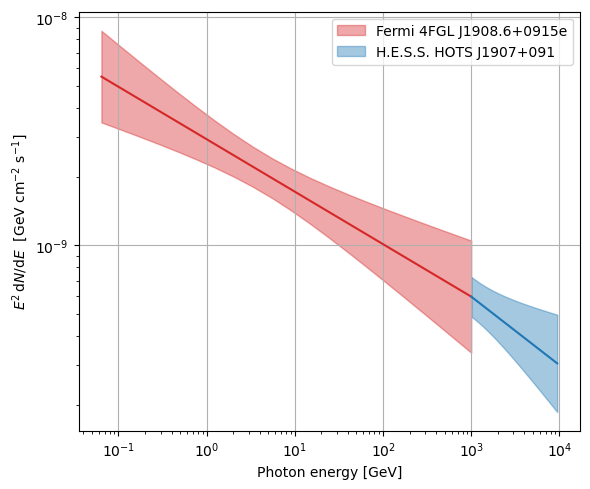

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def load_sed(fname):
    data = np.loadtxt(fname)
    E, Elo, Ehi, F, Ferr_lo, Ferr_hi = data.T
    return E, Elo, Ehi, F

# ------- load central synthetic spectra (no need for errors here) -------
E_f, Elo_f, Ehi_f, F_f = load_sed("FERMI_SYN_50MeV_1TeV.txt")
E_h, Elo_h, Ehi_h, F_h = load_sed("HESS_SYN_1TeV_10TeV.txt")

# ----------------- Fermi band: PL with N0 + Gamma errors -----------------
E0_F = 4.52          # GeV, pivot energy
Gamma_F = 2.23
sigma_Gamma_F = 0.098
rel_sys_F = 0.20

sigma_logF_F = np.sqrt(rel_sys_F**2 + (np.log(E_f / E0_F) * sigma_Gamma_F)**2)

SED_f = E_f**2 * F_f
SED_f_lo = SED_f * np.exp(-sigma_logF_F)
SED_f_hi = SED_f * np.exp(+sigma_logF_F)

# ----------------- HESS band: PL with N0 + Gamma errors ------------------
E0_H = 1000.0       # GeV
Gamma_H = 2.3
sigma_Gamma_H = 0.2
rel_sys_H = 0.20

sigma_logF_H = np.sqrt(rel_sys_H**2 + (np.log(E_h / E0_H) * sigma_Gamma_H)**2)

SED_h = E_h**2 * F_h
SED_h_lo = SED_h * np.exp(-sigma_logF_H)
SED_h_hi = SED_h * np.exp(+sigma_logF_H)

# ----------------- enforce smooth connection at 1 TeV --------------------
E_join = 1e3  # 1 TeV

# Fermi PL normalisation and flux at 1 TeV
N0_F = F_f[-1] * (E_f[-1] / E0_F) ** Gamma_F
F_1TeV_F = N0_F * (E_join / E0_F) ** (-Gamma_F)

# HESS PL normalisation and flux at 1 TeV
N0_H = F_h[0] * (E_h[0] / E0_H) ** Gamma_H
F_1TeV_H = N0_H  # pivot at 1 TeV

# --- 1) renormalise HESS so that F_HESS(1 TeV) = F_Fermi(1 TeV)  ### NEW
scale_HESS = F_1TeV_F / F_1TeV_H
F_h *= scale_HESS
SED_h *= scale_HESS
SED_h_lo *= scale_HESS
SED_h_hi *= scale_HESS

# --- 2) add an explicit point at 1 TeV on both sides  ### NEW
# Fermi point at 1 TeV
sigma_logF_1TeV_F = np.sqrt(
    rel_sys_F**2 + (np.log(E_join / E0_F) * sigma_Gamma_F) ** 2
)
SED_1TeV_F = E_join**2 * F_1TeV_F
SED_1TeV_F_lo = SED_1TeV_F * np.exp(-sigma_logF_1TeV_F)
SED_1TeV_F_hi = SED_1TeV_F * np.exp(+sigma_logF_1TeV_F)

E_f_plot = np.append(E_f, E_join)
SED_f_plot = np.append(SED_f, SED_1TeV_F)
SED_f_lo_plot = np.append(SED_f_lo, SED_1TeV_F_lo)
SED_f_hi_plot = np.append(SED_f_hi, SED_1TeV_F_hi)

# HESS point at 1 TeV (after rescaling)
sigma_logF_1TeV_H = np.sqrt(
    rel_sys_H**2 + (np.log(E_join / E0_H) * sigma_Gamma_H) ** 2
)
SED_1TeV_H = E_join**2 * F_1TeV_F  # same central value by construction
SED_1TeV_H_lo = SED_1TeV_H * np.exp(-sigma_logF_1TeV_H)
SED_1TeV_H_hi = SED_1TeV_H * np.exp(+sigma_logF_1TeV_H)

E_h_plot = np.insert(E_h, 0, E_join)
SED_h_plot = np.insert(SED_h, 0, SED_1TeV_H)
SED_h_lo_plot = np.insert(SED_h_lo, 0, SED_1TeV_H_lo)
SED_h_hi_plot = np.insert(SED_h_hi, 0, SED_1TeV_H_hi)

# ----------------- plot -----------------
fig, ax = plt.subplots(figsize=(6, 5))

# Fermi (red)
ax.fill_between(E_f_plot, SED_f_lo_plot, SED_f_hi_plot,
                alpha=0.4, color="tab:red", label="Fermi 4FGL J1908.6+0915e")
ax.plot(E_f_plot, SED_f_plot, color="tab:red")

# HESS (blue)
ax.fill_between(E_h_plot, SED_h_lo_plot, SED_h_hi_plot,
                alpha=0.4, color="tab:blue", label="H.E.S.S. HOTS J1907+091")
ax.plot(E_h_plot, SED_h_plot, color="tab:blue")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Photon energy [GeV]")
ax.set_ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E$  [GeV cm$^{-2}$ s$^{-1}$]")
ax.legend(loc="best")

ax.xaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.yaxis.set_minor_locator(mticker.LogLocator(subs="auto"))

plt.grid()
plt.tight_layout()
plt.show()

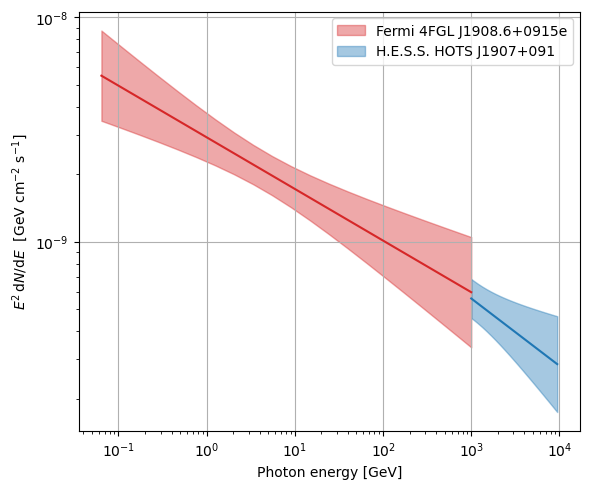

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def load_sed(fname):
    data = np.loadtxt(fname)
    E, Elo, Ehi, F, Ferr_lo, Ferr_hi = data.T
    return E, Elo, Ehi, F

# ------- load central synthetic spectra (no need for errors here) -------
E_f, Elo_f, Ehi_f, F_f = load_sed("FERMI_SYN_50MeV_1TeV.txt")
E_h, Elo_h, Ehi_h, F_h = load_sed("HESS_SYN_1TeV_10TeV.txt")

# ----------------- Fermi band: PL with N0 + Gamma errors -----------------
E0_F = 4.52          # GeV, pivot energy
Gamma_F = 2.23
sigma_Gamma_F = 0.098
rel_sys_F = 0.20

sigma_logF_F = np.sqrt(rel_sys_F**2 + (np.log(E_f / E0_F) * sigma_Gamma_F)**2)

SED_f = E_f**2 * F_f
SED_f_lo = SED_f * np.exp(-sigma_logF_F)
SED_f_hi = SED_f * np.exp(+sigma_logF_F)

# ----------------- HESS band: PL with N0 + Gamma errors ------------------
E0_H = 1000.0       # GeV, 1 TeV
Gamma_H = 2.3
sigma_Gamma_H = 0.2
rel_sys_H = 0.20

sigma_logF_H = np.sqrt(rel_sys_H**2 + (np.log(E_h / E0_H) * sigma_Gamma_H)**2)

SED_h = E_h**2 * F_h
SED_h_lo = SED_h * np.exp(-sigma_logF_H)
SED_h_hi = SED_h * np.exp(+sigma_logF_H)

# ----------------- add explicit point at 1 TeV for both bands -----------
E_join = 1e3  # 1 TeV

# --- Fermi value at 1 TeV (using its PL, keeping its own normalisation)
# normalisation at pivot:
N0_F = F_f[-1] * (E_f[-1] / E0_F) ** Gamma_F
F_join_F = N0_F * (E_join / E0_F) ** (-Gamma_F)

sigma_logF_join_F = np.sqrt(
    rel_sys_F**2 + (np.log(E_join / E0_F) * sigma_Gamma_F) ** 2
)
SED_join_F = E_join**2 * F_join_F
SED_join_F_lo = SED_join_F * np.exp(-sigma_logF_join_F)
SED_join_F_hi = SED_join_F * np.exp(+sigma_logF_join_F)

E_f_band = np.append(E_f, E_join)
SED_f_band = np.append(SED_f, SED_join_F)
SED_f_lo_band = np.append(SED_f_lo, SED_join_F_lo)
SED_f_hi_band = np.append(SED_f_hi, SED_join_F_hi)

# --- HESS value at 1 TeV (its own PL, pivot already at 1 TeV)
N0_H = F_h[0] * (E_h[0] / E0_H) ** Gamma_H  # F(E) = N0 (E/E0)^-Gamma
F_join_H = N0_H  # because E_join = E0_H

sigma_logF_join_H = np.sqrt(
    rel_sys_H**2 + (np.log(E_join / E0_H) * sigma_Gamma_H) ** 2
)
SED_join_H = E_join**2 * F_join_H
SED_join_H_lo = SED_join_H * np.exp(-sigma_logF_join_H)
SED_join_H_hi = SED_join_H * np.exp(+sigma_logF_join_H)

E_h_band = np.insert(E_h, 0, E_join)
SED_h_band = np.insert(SED_h, 0, SED_join_H)
SED_h_lo_band = np.insert(SED_h_lo, 0, SED_join_H_lo)
SED_h_hi_band = np.insert(SED_h_hi, 0, SED_join_H_hi)

# ----------------- plot -----------------
fig, ax = plt.subplots(figsize=(6, 5))

# Fermi (red)
ax.fill_between(E_f_band, SED_f_lo_band, SED_f_hi_band,
                alpha=0.4, color="tab:red", label="Fermi 4FGL J1908.6+0915e")
ax.plot(E_f_band, SED_f_band, color="tab:red")

# HESS (blue)
ax.fill_between(E_h_band, SED_h_lo_band, SED_h_hi_band,
                alpha=0.4, color="tab:blue", label="H.E.S.S. HOTS J1907+091")
ax.plot(E_h_band, SED_h_band, color="tab:blue")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Photon energy [GeV]")
ax.set_ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E$  [GeV cm$^{-2}$ s$^{-1}$]")
ax.legend(loc="best")

ax.xaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.yaxis.set_minor_locator(mticker.LogLocator(subs="auto"))

plt.grid()
plt.tight_layout()
plt.show()

In [55]:
data

energy,energy_lo,energy_hi,flux,flux_err,flux_error_lo,flux_error_hi
GeV,GeV,GeV,1 / (GeV s cm2),1 / (GeV s cm2),1 / (GeV s cm2),1 / (GeV s cm2)
float64,float64,float64,float64,float64,float64,float64
0.064046552,0.05,0.0820392165,1.33904309e-06,2.67808617e-07,2.67808617e-07,2.67808617e-07
0.105086579,0.0820392165,0.134608661,4.43843339e-07,8.87686679e-08,8.87686679e-08,8.87686679e-08
0.172424412,0.134608661,0.220863782,1.47117678e-07,2.94235357e-08,2.94235357e-08,2.94235357e-08
0.282911273,0.220863782,0.362389832,4.87640781e-08,9.75281561e-09,9.75281561e-09,9.75281561e-09
0.464196384,0.362389832,0.594603558,1.61634913e-08,3.23269826e-09,3.23269826e-09,3.23269826e-09
0.761646154,0.594603558,0.9756162,5.35760053e-09,1.07152011e-09,1.07152011e-09,1.07152011e-09
1.24969707,0.9756162,1.60077577,1.77584675e-09,3.5516935e-10,3.5516935e-10,3.5516935e-10
2.05048338,1.60077577,2.6265278,5.88627625e-10,1.17725525e-10,1.17725525e-10,1.17725525e-10


In [56]:
fermi_data

energy,energy_lo,energy_hi,flux,flux_err,is_ul
GeV,GeV,GeV,1 / (GeV s cm2),1 / (GeV s cm2),
float64,float64,float64,float64,float64,bool
0.17320508075688773,0.1,0.3,2.8385000000000004e-07,2.79125e-07,False
0.5477225575051662,0.3,1.0,1.3771428571428575e-08,5.645714285714286e-09,False
1.7320508075688772,1.0,3.0,1.0925e-09,2.2437500000000001e-10,False
5.477225575051661,3.0,10.0,5.7985714285714296e-11,1.8157142857142862e-11,False
17.320508075688775,10.0,30.0,4.007e-12,2.0345000000000003e-12,False
54.772255750516614,30.0,100.0,2.1157142857142857e-13,nan,True
316.2277660168379,100.0,1000.0,2.496666666666667e-14,1.0661666666666668e-14,False


In [57]:
model_best

<Quantity [7.74733959e-16, 6.86087291e-16, 6.07557222e-16, 5.37991642e-16,
           4.76369426e-16, 4.21785567e-16, 3.73437987e-16, 3.30615846e-16,
           2.92689181e-16, 2.59099713e-16, 2.29352705e-16, 2.03009740e-16,
           1.79682322e-16, 1.59026197e-16, 1.40736326e-16, 1.24542424e-16,
           1.10205009e-16, 9.75118952e-17, 8.62750916e-17, 7.63280446e-17,
           6.75232007e-17, 5.97298419e-17, 5.28321701e-17, 4.67276067e-17,
           4.13252877e-17, 3.65447284e-17, 3.23146407e-17, 2.85718847e-17,
           2.52605400e-17, 2.23310818e-17, 1.97396516e-17, 1.74474109e-17,
           1.54199677e-17, 1.36268691e-17, 1.20411517e-17, 1.06389424e-17,
           9.39910584e-18, 8.30293114e-18, 7.33385471e-18, 6.47721472e-18,
           5.72003344e-18, 5.05082451e-18, 4.45942212e-18, 3.93682982e-18,
           3.47508648e-18, 3.06714760e-18, 2.70678023e-18, 2.38846980e-18,
           2.10733775e-18, 1.85906842e-18, 1.63984442e-18, 1.44628937e-18,
           1.27541717e-18

UnitConversionError: 'GeV' (energy/torque/work) and 'GeV / (s cm2)' (energy flux/flux/irradiance) are not convertible

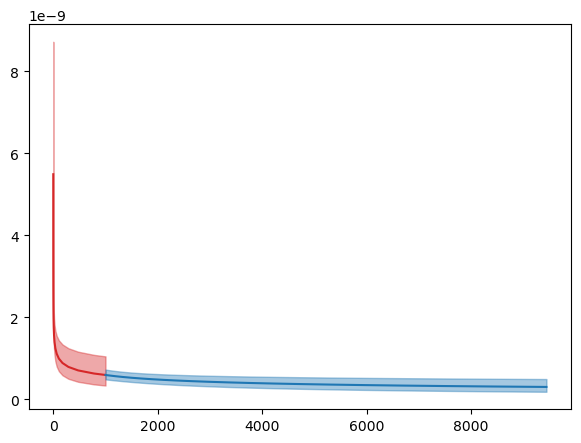

In [58]:
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# =====================================================================
# 1) Best-fit Naima model + data  --> convert to SED in GeV units
# =====================================================================

# MCMC samples (already computed somewhere above)
samples = sampler.get_chain(flat=True)
log10_norm_med = np.median(samples[:, 0])
index_med      = np.median(samples[:, 1])
log10_Ecut_med = np.median(samples[:, 2])  # log10(Ecut / TeV)

# Smooth energy grid for model (same range as data)
E_plot = np.logspace(
    np.log10(data["energy"].min()),
    np.log10(data["energy"].max()),
    200
) * data["energy"].unit

# Model dN/dE
model_best, _, _ = IC_ECPL(
    np.array([log10_norm_med, index_med, log10_Ecut_med]),
    {"energy": E_plot},
)

# --- convert to GeV-based SED: E^2 dN/dE [GeV cm^-2 s^-1] ---

E_data_GeV = data["energy"].to(u.GeV)
E_plot_GeV = E_plot.to(u.GeV)

# flux is dN/dE; convert to per GeV
flux_data_GeV  = data["flux"].to(1 / (u.cm**2 * u.s * u.GeV))
flux_model_GeV = model_best.to(1 / (u.cm**2 * u.s * u.GeV))

sed_data  = (E_data_GeV**2 * flux_data_GeV).to(u.GeV / (u.cm**2 * u.s))
sed_model = (E_plot_GeV**2 * flux_model_GeV).to(u.GeV / (u.cm**2 * u.s))

# errors for the "data" table (not used for plotting anymore, but kept if needed)
flux_err      = 0.5 * (data["flux_error_hi"] - data["flux_error_lo"])
flux_err_GeV  = flux_err.to(1 / (u.cm**2 * u.s * u.GeV))
sed_err       = (E_data_GeV**2 * flux_err_GeV).to(u.GeV / (u.cm**2 * u.s))

# =====================================================================
# 2) Fermi/HESS synthetic bands (as in your second script)
# =====================================================================

def load_sed(fname):
    data_arr = np.loadtxt(fname)
    E, Elo, Ehi, F, Ferr_lo, Ferr_hi = data_arr.T
    return E, Elo, Ehi, F

# energies in GeV, flux in ph / (cm^2 s GeV)
E_f, Elo_f, Ehi_f, F_f = load_sed("FERMI_SYN_50MeV_1TeV.txt")
E_h, Elo_h, Ehi_h, F_h = load_sed("HESS_SYN_1TeV_10TeV.txt")

# ----------------- Fermi band -----------------
E0_F = 4.52          # GeV
Gamma_F = 2.23
sigma_Gamma_F = 0.098
rel_sys_F = 0.20

sigma_logF_F = np.sqrt(rel_sys_F**2 + (np.log(E_f / E0_F) * sigma_Gamma_F)**2)

SED_f    = E_f**2 * F_f
SED_f_lo = SED_f * np.exp(-sigma_logF_F)
SED_f_hi = SED_f * np.exp(+sigma_logF_F)

# ----------------- HESS band ------------------
E0_H = 1000.0       # GeV
Gamma_H = 2.3
sigma_Gamma_H = 0.2
rel_sys_H = 0.20

sigma_logF_H = np.sqrt(rel_sys_H**2 + (np.log(E_h / E0_H) * sigma_Gamma_H)**2)

SED_h    = E_h**2 * F_h
SED_h_lo = SED_h * np.exp(-sigma_logF_H)
SED_h_hi = SED_h * np.exp(+sigma_logF_H)

# ----------------- enforce smooth connection at 1 TeV -----------------
E_join = 1e3  # 1 TeV, in GeV

# Fermi PL normalisation and flux at 1 TeV
N0_F      = F_f[-1] * (E_f[-1] / E0_F) ** Gamma_F
F_1TeV_F  = N0_F * (E_join / E0_F) ** (-Gamma_F)

# HESS PL normalisation and flux at 1 TeV
N0_H     = F_h[0] * (E_h[0] / E0_H) ** Gamma_H
F_1TeV_H = N0_H  # pivot at 1 TeV

# 1) rescale HESS so that F_HESS(1 TeV) = F_Fermi(1 TeV)
scale_HESS = F_1TeV_F / F_1TeV_H
F_h       *= scale_HESS
SED_h     *= scale_HESS
SED_h_lo  *= scale_HESS
SED_h_hi  *= scale_HESS

# 2) add explicit point at 1 TeV on both sides
# Fermi
sigma_logF_1TeV_F = np.sqrt(
    rel_sys_F**2 + (np.log(E_join / E0_F) * sigma_Gamma_F) ** 2
)
SED_1TeV_F    = E_join**2 * F_1TeV_F
SED_1TeV_F_lo = SED_1TeV_F * np.exp(-sigma_logF_1TeV_F)
SED_1TeV_F_hi = SED_1TeV_F * np.exp(+sigma_logF_1TeV_F)

E_f_plot      = np.append(E_f, E_join)
SED_f_plot    = np.append(SED_f, SED_1TeV_F)
SED_f_lo_plot = np.append(SED_f_lo, SED_1TeV_F_lo)
SED_f_hi_plot = np.append(SED_f_hi, SED_1TeV_F_hi)

# HESS (after rescaling)
sigma_logF_1TeV_H = np.sqrt(
    rel_sys_H**2 + (np.log(E_join / E0_H) * sigma_Gamma_H) ** 2
)
SED_1TeV_H    = E_join**2 * F_1TeV_F
SED_1TeV_H_lo = SED_1TeV_H * np.exp(-sigma_logF_1TeV_H)
SED_1TeV_H_hi = SED_1TeV_H * np.exp(+sigma_logF_1TeV_H)

E_h_plot      = np.insert(E_h, 0, E_join)
SED_h_plot    = np.insert(SED_h, 0, SED_1TeV_H)
SED_h_lo_plot = np.insert(SED_h_lo, 0, SED_1TeV_H_lo)
SED_h_hi_plot = np.insert(SED_h_hi, 0, SED_1TeV_H_hi)

# =====================================================================
# 3) ONE combined plot: bands + Fermi table data points + model
# =====================================================================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Fermi band (red) ---
ax.fill_between(
    E_f_plot, SED_f_lo_plot, SED_f_hi_plot,
    alpha=0.4, color="tab:red", label="Fermi synthetic band",
)
ax.plot(E_f_plot, SED_f_plot, color="tab:red")

# --- HESS band (blue) ---
ax.fill_between(
    E_h_plot, SED_h_lo_plot, SED_h_hi_plot,
    alpha=0.4, color="tab:blue", label="H.E.S.S. synthetic band",
)
ax.plot(E_h_plot, SED_h_plot, color="tab:blue")

# ============================================================
# Fermi TABLE DATA (replaces Naima black dots)
# ============================================================

mask_det = ~fermi_data["is_ul"]

# These already carry units from the astropy Table:
E_fermi = fermi_data["energy"][mask_det]      # GeV
F_fermi = fermi_data["flux"][mask_det]        # 1 / (GeV s cm2)
Ferr    = fermi_data["flux_err"][mask_det]    # 1 / (GeV s cm2)

SED_fermi     = (E_fermi**2 * F_fermi).to(u.GeV / (u.cm**2 * u.s))
SED_fermi_err = (E_fermi**2 * Ferr).to(u.GeV / (u.cm**2 * u.s))

ax.errorbar(
    E_fermi.value,
    SED_fermi.value,
    yerr=SED_fermi_err.value,
    fmt="o",
    ms=5,
    color="k",
    label="Fermi-LAT data",
)

# --- Upper limits ---
mask_ul = fermi_data["is_ul"]

if np.any(mask_ul):
    E_ul  = fermi_data["energy"][mask_ul]
    F_ul  = fermi_data["flux"][mask_ul]
    SED_ul = (E_ul**2 * F_ul).to(u.GeV / (u.cm**2 * u.s))

    ax.scatter(
        E_ul.value,
        SED_ul.value,
        marker="v",
        color="k",
        label="Fermi UL",
    )

# ============================================================

# --- Naima best-fit model (black dashed line) ---
ax.plot(
    E_plot_GeV.value,
    sed_model.value,
    color="k",
    ls="--",
    label="Best-fit IC model",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Photon energy [GeV]")
ax.set_ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E$  [GeV cm$^{-2}$ s$^{-1}$]")

ax.legend(loc="best")
ax.xaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.yaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Read the catalogue Fermi data

In [48]:
from astropy.io import ascii
from astropy.table import Table
import astropy.units as u
import numpy as np


def read_fermi_catalog_spectrum(filename: str) -> Table:
    """Read Fermi catalog SED file and return Naima-ready differential spectrum.

    File layout (what you showed):

      e_min       e_max        flux  ...
       MeV         MeV     1 / (s cm2) ...
    ---------- ----------- ----------- ...
        50.000     100.000   1.341e-09 ...

    We skip the first 3 lines and parse the rest as a whitespace-separated table.
    """

    # Read file and strip the 3 header lines (names, units, dashes)
    with open(filename, "r") as f:
        lines = f.readlines()

    data_lines = "".join(lines[3:])  # from the first numeric row onward

    colnames = [
        "e_min",
        "e_max",
        "flux",
        "flux_errn",
        "flux_errp",
        "e2dnde",
        "e2dnde_errn",
        "e2dnde_errp",
        "is_ul",
        "flux_ul",
        "e2dnde_ul",
        "sqrt_ts",
    ]

    raw = ascii.read(
        data_lines,
        format="basic",
        guess=False,
        names=colnames,
    )

    # Energies in MeV -> GeV
    Emin = raw["e_min"] * u.MeV
    Emax = raw["e_max"] * u.MeV
    Emean = np.sqrt(Emin * Emax)

    # Integrated flux per bin
    F_int = raw["flux"] * (1 / (u.cm**2 * u.s))
    Ferr_lo = raw["flux_errn"] * (1 / (u.cm**2 * u.s))
    Ferr_hi = raw["flux_errp"] * (1 / (u.cm**2 * u.s))

    dE = (Emax - Emin)

    # Differential flux dN/dE
    dnde = (F_int / dE).to(1 / (u.cm**2 * u.s * u.GeV))
    dnde_err_lo = (Ferr_lo / dE).to(1 / (u.cm**2 * u.s * u.GeV))
    dnde_err_hi = (Ferr_hi / dE).to(1 / (u.cm**2 * u.s * u.GeV))
    dnde_err = 0.5 * (dnde_err_lo + dnde_err_hi)

    # Build Naima-style table
    data = Table()
    data["energy"] = Emean.to(u.GeV)
    data["energy_lo"] = Emin.to(u.GeV)
    data["energy_hi"] = Emax.to(u.GeV)
    data["flux"] = dnde
    data["flux_err"] = dnde_err

    # is_ul is a string column ("True"/"False") → convert to bool
    data["is_ul"] = np.array(raw["is_ul"] == "True", dtype=bool)

    return data

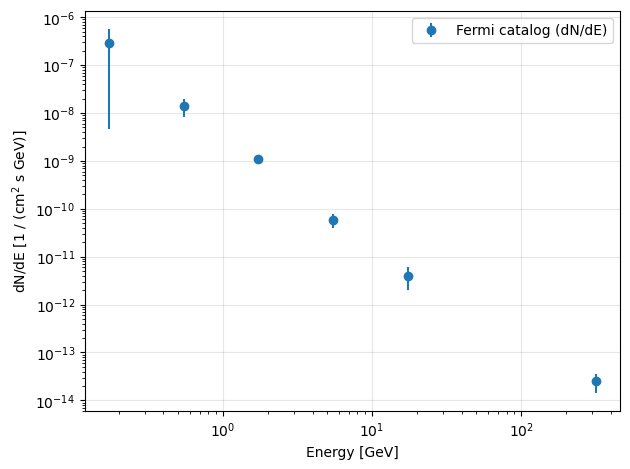

In [49]:
fermi_data = read_fermi_catalog_spectrum(
    "/Users/vdk/science/sgr1900+14/FERMI_CATALOG.txt"
)

# For fitting only detections:
mask_det = ~fermi_data["is_ul"]
fermi_det = fermi_data[mask_det]

# Quick check plot in the same units as your IC model
import matplotlib.pyplot as plt

plt.errorbar(
    fermi_det["energy"].value,
    fermi_det["flux"].value,
    yerr=fermi_det["flux_err"].value,
    fmt="o",
    label="Fermi catalog (dN/dE)",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("dN/dE [1 / (cm$^2$ s GeV)]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
fermi_data

energy,energy_lo,energy_hi,flux,flux_err,is_ul
GeV,GeV,GeV,1 / (GeV s cm2),1 / (GeV s cm2),
float64,float64,float64,float64,float64,bool
0.17320508075688773,0.1,0.3,2.8385000000000004e-07,2.79125e-07,False
0.5477225575051662,0.3,1.0,1.3771428571428575e-08,5.645714285714286e-09,False
1.7320508075688772,1.0,3.0,1.0925e-09,2.2437500000000001e-10,False
5.477225575051661,3.0,10.0,5.7985714285714296e-11,1.8157142857142862e-11,False
17.320508075688775,10.0,30.0,4.007e-12,2.0345000000000003e-12,False
54.772255750516614,30.0,100.0,2.1157142857142857e-13,nan,True
316.2277660168379,100.0,1000.0,2.496666666666667e-14,1.0661666666666668e-14,False


# Read the table 

In [18]:
from astropy.io import ascii
from astropy.table import Table
import astropy.units as u
import numpy as np


def read_ic_sed(filename: str) -> Table:
    """Read IC SED file and return a Naima-ready data table.

    Parameters
    ----------
    filename : str
        Path to the text file (like the one you pasted).

    Returns
    -------
    data : astropy.table.Table
        Columns:
        - energy      : bin centre (GeV)
        - energy_lo   : lower bin edge (GeV)
        - energy_hi   : upper bin edge (GeV)
        - flux        : dN/dE  [1 / (cm2 s GeV)]
        - flux_err    : symmetric error on flux, same units
    """
    # Read, ignoring the commented header line
    raw = ascii.read(
        filename,
        comment="#",
        names=[
            "energy",
            "energy_edge_lo",
            "energy_edge_hi",
            "flux",
            "flux_err_lo",
            "flux_err_hi",
        ],
    )

    # Build Naima-style table with units
    data = Table()

    data["energy"] = raw["energy"] * u.GeV
    data["energy_lo"] = raw["energy_edge_lo"] * u.GeV
    data["energy_hi"] = raw["energy_edge_hi"] * u.GeV

    data["flux"] = raw["flux"] * (1 / (u.cm**2 * u.s * u.GeV))

    # symmetric error; here lo/hi are equal, but keep the general form
    flux_err = 0.5 * (raw["flux_err_lo"] + raw["flux_err_hi"])
    data["flux_err"] = flux_err * (1 / (u.cm**2 * u.s * u.GeV))
    data["flux_error_lo"] = raw["flux_err_lo"] * (1 / (u.cm**2 * u.s * u.GeV))
    data["flux_error_hi"] = raw["flux_err_hi"] * (1 / (u.cm**2 * u.s * u.GeV))
    return data

In [19]:
data = read_ic_sed("/Users/vdk/science/sgr1900+14/FERMI_HESS_SYN_50MeV_1TeV.txt")
data

energy,energy_lo,energy_hi,flux,flux_err,flux_error_lo,flux_error_hi
GeV,GeV,GeV,1 / (GeV s cm2),1 / (GeV s cm2),1 / (GeV s cm2),1 / (GeV s cm2)
float64,float64,float64,float64,float64,float64,float64
0.064046552,0.05,0.0820392165,1.33904309e-06,2.67808617e-07,2.67808617e-07,2.67808617e-07
0.105086579,0.0820392165,0.134608661,4.43843339e-07,8.87686679e-08,8.87686679e-08,8.87686679e-08
0.172424412,0.134608661,0.220863782,1.47117678e-07,2.94235357e-08,2.94235357e-08,2.94235357e-08
0.282911273,0.220863782,0.362389832,4.87640781e-08,9.75281561e-09,9.75281561e-09,9.75281561e-09
0.464196384,0.362389832,0.594603558,1.61634913e-08,3.23269826e-09,3.23269826e-09,3.23269826e-09
0.761646154,0.594603558,0.9756162,5.35760053e-09,1.07152011e-09,1.07152011e-09,1.07152011e-09
1.24969707,0.9756162,1.60077577,1.77584675e-09,3.5516935e-10,3.5516935e-10,3.5516935e-10
2.05048338,1.60077577,2.6265278,5.88627625e-10,1.17725525e-10,1.17725525e-10,1.17725525e-10


# Fitting the mode with naima for Inverse Compton case 

In [20]:
from IC_ECPL_model import IC_ECPL, IC_ECPL_lnprior
import naima

p0 = np.array([44.5, 2.2, 1.5])   # log10_norm, index, log10_Ecut_TeV (~30 TeV)
labels = ["log10_norm", "index", "log10_Ecut_TeV"]

sampler, pos = naima.run_sampler(
    data_table=data,
    p0=p0,
    labels=labels,
    model=IC_ECPL,
    prior=IC_ECPL_lnprior,
    nwalkers=96,
    nburn=200,
    nrun=400,
    threads=8,    # or whatever your CPU supports
)

Burning in the 96 walkers with 200 steps...


/Users/vdk/miniforge3/envs/naima/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]



Progress of the run: 0 percent (0 of 200 steps)
                           --log10_norm--- -----index----- log10_Ecut_TeV-
  Last ensemble median :      43.8            2.17            1.53      
  Last ensemble std    :       3.9            0.24            0.172     
  Last ensemble lnprob :  avg: -inf, max: -565.025

Progress of the run: 5 percent (10 of 200 steps)
                           --log10_norm--- -----index----- log10_Ecut_TeV-
  Last ensemble median :      38.9            2.26             1.5      
  Last ensemble std    :       3.1            0.324           0.353     
  Last ensemble lnprob :  avg: -91613722980708174876639232.000, max: -93.920

Progress of the run: 10 percent (20 of 200 steps)
                           --log10_norm--- -----index----- log10_Ecut_TeV-
  Last ensemble median :      36.4            2.29            1.54      
  Last ensemble std    :      1.82            0.336           0.515     
  Last ensemble lnprob :  avg: -461054974708201664.000, max

# Extracting fit results

In [22]:
samples = sampler.get_chain(flat=True)

log10_norm_samples = samples[:, 0]
index_samples = samples[:, 1]

# Median + 1σ credible intervals
log10_norm_med = np.median(log10_norm_samples)
log10_norm_lo, log10_norm_hi = np.percentile(log10_norm_samples, [16, 84])

index_med = np.median(index_samples)
index_lo, index_hi = np.percentile(index_samples, [16, 84])

print("Best-fit electron spectrum parameters:")
print(f"log10(norm) = {log10_norm_med:.3f} "
      f"(-{log10_norm_med-log10_norm_lo:.3f}, +{log10_norm_hi-log10_norm_med:.3f})")

print(f"index = {index_med:.3f} "
      f"(-{index_med-index_lo:.3f}, +{index_hi-index_med:.3f})")

Best-fit electron spectrum parameters:
log10(norm) = 35.534 (-0.016, +0.015)
index = 3.013 (-0.017, +0.015)


In [23]:
lnprob = sampler.get_log_prob(flat=True)
best_idx = np.argmax(lnprob)
best_fit_pars = samples[best_idx]

print("MAP parameters:", best_fit_pars)

MAP parameters: [35.53117494  3.01476343  2.9979711 ]


In [27]:
blobs = sampler.get_blobs(flat=True)

We_samples = blobs[:, 2]    # Quantity array

We_med = np.median(We_samples)
We_lo, We_hi = np.percentile(We_samples, [16, 84])

print("\nTotal energy in electrons:")
print(f"Wp(Ee > 1 GeV) = {We_med:.3e}")
print(f"-1σ = {We_med - We_lo:.3e}")
print(f"+1σ = {We_hi - We_med:.3e}")


Total energy in electrons:
Wp(Ee > 1 GeV) = 5.912e+50 erg
-1σ = 6.115e+49 erg
+1σ = 5.940e+49 erg


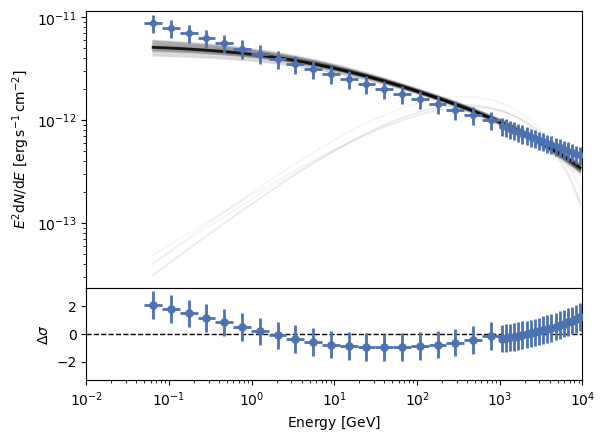

In [34]:
import matplotlib.pyplot as plt
import naima

fig = naima.plot_fit(sampler)
plt.show()

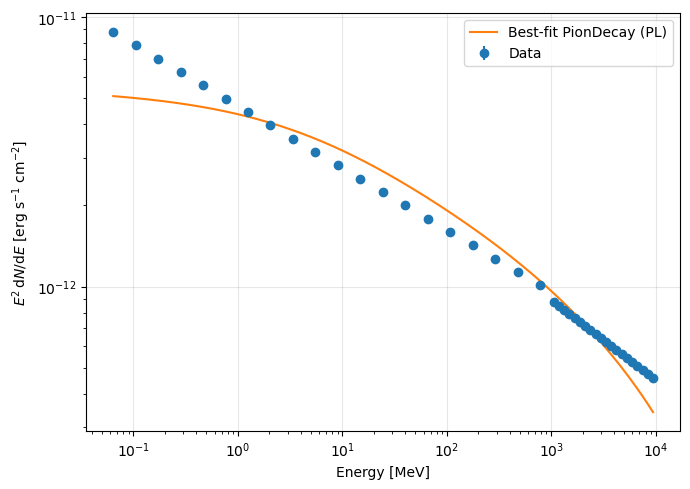

In [42]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# 1. Best-fit parameters (median or MAP)
samples = sampler.get_chain(flat=True)
log10_norm_med = np.median(samples[:, 0])
index_med = np.median(samples[:, 1])
log10_Ecut_med = np.median(samples[:, 2])  # log10(Ecut/TeV)

# 2. Smooth energy grid
E_plot = np.logspace(
    np.log10(data["energy"].min()),
    np.log10(data["energy"].max()),
    200
) * data["energy"].unit  # MeV

# 3. Model dN/dE on that grid
model_best, _, _ = IC_ECPL(
    np.array([log10_norm_med, index_med, log10_Ecut_med]),
    {"energy": E_plot},
)

# 4. Convert data & model to SED: E^2 dN/dE in erg cm^-2 s^-1
E_data_erg = data["energy"].to(u.erg)
E_plot_erg = E_plot.to(u.erg)

flux_data_erg = data["flux"].to(1 / (u.cm**2 * u.s * u.erg))
flux_model_erg = model_best.to(1 / (u.cm**2 * u.s * u.erg))

sed_data = (E_data_erg**2 * flux_data_erg).to(u.erg / (u.cm**2 * u.s))
sed_model = (E_plot_erg**2 * flux_model_erg).to(u.erg / (u.cm**2 * u.s))

# symmetric error if you want
flux_err = 0.5 * (data["flux_error_hi"] - data["flux_error_lo"])
flux_err_erg = flux_err.to(1 / (u.cm**2 * u.s * u.erg))
sed_err = (E_data_erg**2 * flux_err_erg).to(u.erg / (u.cm**2 * u.s))

# 5. Plot SED like naima.plot_fit
plt.figure(figsize=(7,5))
plt.errorbar(
    data["energy"].value,
    sed_data.value,
    yerr=sed_err.value,
    fmt="o",
    label="Data",
)
plt.plot(
    E_plot.value,
    sed_model.value,
    label="Best-fit PionDecay (PL)",
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [MeV]")
plt.ylabel(r"$E^2\, \mathrm{d}N/\mathrm{d}E$ [erg s$^{-1}$ cm$^{-2}$]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot the fitted spectrum

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import astropy.units as u

# --- Load Fermi table and convert to per-GeV ---
fermi = np.loadtxt("FERMI_CATALOG.txt", comments="#")
Ecen_mev, Elo_mev, Ehi_mev, flux_int, err_lo, err_hi = fermi.T

Elo = (Elo_mev * u.MeV).to(u.GeV)
Ehi = (Ehi_mev * u.MeV).to(u.GeV)
Ecen = np.sqrt(Elo * Ehi)  # geometric center in GeV

width = Ehi - Elo
flux = (flux_int * (1 / (u.cm**2 * u.s)) / width).to(1 / (u.cm**2 * u.s * u.GeV))
err_lo = (err_lo * (1 / (u.cm**2 * u.s)) / width).to(flux.unit)
err_hi = (err_hi * (1 / (u.cm**2 * u.s)) / width).to(flux.unit)

# SED (GeV cm^-2 s^-1); bounds for fill_between
sed = (Ecen**2 * flux).to(u.GeV / (u.cm**2 * u.s))
sed_err_lo = (Ecen**2 * err_lo).to(sed.unit)
sed_err_hi = (Ecen**2 * err_hi).to(sed.unit)
SED_f_plot = sed.value
SED_f_lo_plot = np.maximum((sed - sed_err_lo).value, 0)  # clip at 0 to avoid negatives
SED_f_hi_plot = (sed + sed_err_hi).value
E_f_plot = Ecen.value  # GeV for x-axis

# --- (Example) load HESS the same way if needed ---
# hess = np.loadtxt("HESS_SYN_1TeV_10TeV.txt", comments="#")
# ...compute E_h_plot, SED_h_plot, SED_h_lo_plot, SED_h_hi_plot similarly...

# --- Model on smooth grid in GeV ---
samples = sampler.get_chain(flat=True)
log10_norm_med = np.median(samples[:, 0])
index_med = np.median(samples[:, 1])
log10_Ecut_med = np.median(samples[:, 2])

E_plot = np.logspace(np.log10(Elo.min().value), np.log10(Ehi.max().value), 200) * u.GeV
model_best, _, _ = IC_ECPL(
    np.array([log10_norm_med, index_med, log10_Ecut_med]),
    {"energy": E_plot},
)
sed_model = (E_plot**2 * model_best.to(flux.unit)).to(u.GeV / (u.cm**2 * u.s))

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(E_plot.value, sed_model.value, color="k", label="Best-fit model")

ax.fill_between(E_f_plot, SED_f_lo_plot, SED_f_hi_plot,
                alpha=0.4, color="tab:red", label="Fermi 4FGL J1908.6+0915e")
ax.plot(E_f_plot, SED_f_plot, color="tab:red")

# ax.fill_between(E_h_plot, SED_h_lo_plot, SED_h_hi_plot,
#                 alpha=0.4, color="tab:blue", label="H.E.S.S. HOTS J1907+091")
# ax.plot(E_h_plot, SED_h_plot, color="tab:blue")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Photon energy [GeV]")
ax.set_ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E$  [GeV cm$^{-2}$ s$^{-1}$]")
ax.legend(loc="best")
ax.xaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.yaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


ValueError: could not convert string 'e_min' to float64 at row 0, column 1.